## ⚽📊 Building Player Profiles with Percentile Radar Charts

**Competition:** Simulated Top European League  
**Data:** Synthetic Player Performance Dataset  
**Purpose:** Demonstrate how percentile-based radar charts can be used to profile football players across different roles  
**Methods:** Synthetic Data Generation, Feature Engineering, Percentile Profiling, Radar Visualisation  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)

**Medium Article:** *(to be published)*

---

**Notebook first written:** `28/03/2026`  
**Last updated:** `29/03/2026`

---

> Modern football analytics increasingly relies on multidimensional player evaluation. Rather than focusing on a single statistic such as goals or assists, analysts often examine a broad set of performance indicators to understand how players contribute across different phases of the game.
>
> This notebook demonstrates how percentile-based radar charts (commonly known as *pizza charts* in football analytics) can be used to build intuitive player profiles. By comparing a player’s metrics against positional peers, these visualisations highlight relative strengths and weaknesses across several aspects of performance.
>
> To illustrate the full workflow, a synthetic dataset of professional male players is generated programmatically. The dataset includes multiple positional groups — centre forwards, wide attackers, midfielders, full backs, and central defenders — and simulates realistic statistical relationships between shooting volume, conversion rates, chance creation, passing contribution, and off-ball movement.
>
> Once the dataset is constructed, player metrics are converted into percentiles either relative to their position or across the entire player pool. These percentiles are then visualised using radar charts to produce compact performance profiles and player comparisons.
>
> While the data in this notebook is simulated, the methodology reflects common practices used in modern football analytics workflows.

# Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import matplotlib.colors as mc
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch

# Football visualisation
from mplsoccer import PyPizza

# Statistics
from scipy.stats import rankdata

# Utility
import colorsys

# Features, Synthetic Stats, and Helper Functions

In [2]:
np.random.seed(14)

positions = [
    "Center Forward",
    "Wide Attacker",
    "Midfield",
    "Full Back",
    "Central Defender"
]

teams = ["United", "City", "Rovers", "Athletic", "Sporting"]

players = []
player_id = 1


def pos_dist(pos):

    if pos == "Center Forward":
        shots = np.random.normal(3.6, 0.8)
        difficulty = np.random.normal(0.35, 0.07)

    elif pos == "Wide Attacker":
        shots = np.random.normal(2.9, 0.7)
        difficulty = np.random.normal(0.42, 0.07)

    elif pos == "Midfield":
        shots = np.random.normal(1.6, 0.5)
        difficulty = np.random.normal(0.52, 0.08)

    elif pos == "Full Back":
        shots = np.random.normal(1.0, 0.4)
        difficulty = np.random.normal(0.60, 0.08)

    elif pos == "Central Defender":
        shots = np.random.normal(0.4, 0.2)
        difficulty = np.random.normal(0.70, 0.08)

    shots = max(shots, 0.1)

    base_conversion = 0.18 - (difficulty * 0.15)
    conversion = np.random.normal(base_conversion, 0.02)
    conversion = np.clip(conversion, 0.03, 0.35)

    goals = shots * conversion

    goals_per90 = goals
    npxg = goals * np.random.normal(1.05, 0.08)

    npxg = max(npxg, 0)

    return {
        "shots_per90_total": shots,
        "conversion_rate": conversion,
        "shots_difficulty_index": difficulty,

        "goals_per90": goals_per90,
        "NPxG90": npxg,
        "xG90": npxg + np.random.normal(0.01, 0.01),

        "assists_per90": np.random.normal(0.15, 0.06),
        "xA90": np.random.normal(0.18, 0.06),

        "xGChain90": np.random.normal(0.80, 0.20),
        "xGBuildup90": np.random.normal(0.40, 0.15),

        "total_pass_value_per90": np.random.normal(0.8, 0.3),
        "possession_line_breaks_per90": np.random.normal(3.0, 1.0),

        "passes_attempted_per90": np.random.normal(50, 15),
        "avg_decision_quality": np.random.normal(0.64, 0.05),
        "completion_minus_xpass_per_pass": np.random.normal(0.0, 0.02),

        "total_xthreat_available_per90": np.random.normal(0.75, 0.25),

        "offball_runs_total_per90": np.random.normal(35, 10),
        "possession_progression_total_per90": np.random.normal(7, 2),

        "obe_total_events_per90": np.random.normal(9, 3),
        "obe_possession_losses_forced_per90": np.random.normal(1.5, 0.5)
    }


for pos in positions:
    for i in range(35):

        metrics = pos_dist(pos)

        player = {
            "player_id": player_id,
            "player_name": f"Player {player_id}",
            "position_group": pos,
            "team": np.random.choice(teams),
            "min": np.random.randint(700, 3000)
        }

        player.update(metrics)

        players.append(player)
        player_id += 1


df_fake = pd.DataFrame(players)

In [6]:
df_fake

,player_id,player_name,position_group,team,min,shots_per90_total,conversion_rate,shots_difficulty_index,goals_per90,NPxG90,...,total_pass_value_per90,possession_line_breaks_per90,passes_attempted_per90,avg_decision_quality,completion_minus_xpass_per_pass,total_xthreat_available_per90,offball_runs_total_per90,possession_progression_total_per90,obe_total_events_per90,obe_possession_losses_forced_per90
0,1,Player 1,Center Forward,Athletic,727,4.841071,0.130148,0.355543,0.630056,0.657913,...,1.125359,2.813711,50.219921,0.586222,0.012845,0.704916,41.203003,8.621949,11.333808,1.381255
1,2,Player 2,Center Forward,Sporting,1034,2.086470,0.097461,0.410770,0.203349,0.196418,...,0.827848,2.824497,41.373191,0.715731,-0.000436,0.806000,29.717124,4.791610,6.299756,2.178106
2,3,Player 3,Center Forward,United,1216,4.277371,0.138280,0.436525,0.591473,0.578882,...,0.971175,3.893749,61.560639,0.698792,-0.015466,0.881667,48.872623,8.803737,9.657558,1.589354
3,4,Player 4,Center Forward,City,2744,2.946454,0.126297,0.405786,0.372127,0.448551,...,0.622909,2.848730,36.934343,0.558532,-0.016178,0.396947,35.645183,5.394962,13.236769,1.430824
4,5,Player 5,Center Forward,Rovers,2874,3.726218,0.120340,0.379930,0.448414,0.460330,...,0.668421,3.681915,25.706110,0.671028,0.021618,0.679032,50.771967,7.524694,5.202988,1.613311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,171,Player 171,Central Defender,Athletic,913,0.182693,0.107397,0.639131,0.019621,0.019286,...,1.057090,2.635874,-1.197709,0.585536,-0.026641,0.605241,41.455032,7.061692,8.024699,1.715257
171,172,Player 172,Central Defender,Rovers,718,0.409544,0.063463,0.733741,0.025991,0.026115,...,0.836659,0.731782,57.691429,0.603428,-0.009118,0.625616,21.234539,8.614990,8.944167,1.929899
172,173,Player 173,Central Defender,Sporting,1728,0.262918,0.061420,0.811838,0.016149,0.018021,...,1.126506,2.023536,16.931582,0.589261,-0.013917,0.666668,38.200289,5.158980,12.571100,1.687897
173,174,Player 174,Central Defender,Sporting,1328,0.422049,0.030000,0.835081,0.012661,0.011745,...,0.279845,2.858896,54.428622,0.662383,0.003434,0.576889,31.848938,3.712825,12.217837,1.038919


# Pizza Plot Function and Examples

In [12]:
# =================
# GLOBAL FONT SIZE
# =================
plt.rcParams["font.size"] = 11


# ========
# CONFIG
# ========
font_normal = FontProperties(family="DejaVu Sans", size=11)
font_bold = FontProperties(family="DejaVu Sans", weight="bold", size=14)


# ========
# FEATURE GROUPS
# ========
FEATURE_GROUPS = {

    "Finishing": [
        "shots_per90_total",
        "shots_difficulty_index",
        "conversion_rate",
        "xG90",
        "NPxG90",
        "goals_per90",
    ],

    "Chance Generation": [
        "assists_per90",
        "xA90",
        "xGChain90",
        "xGBuildup90",
        "total_pass_value_per90",
        "possession_line_breaks_per90",
    ],

    "Involvement": [
        "passes_attempted_per90",
        "avg_decision_quality",
        "completion_minus_xpass_per_pass",
        "total_xthreat_available_per90",
        "offball_runs_total_per90",
        "possession_progression_total_per90",
    ],

    "Out of Possession": [
        "obe_total_events_per90",
        "obe_possession_losses_forced_per90",
    ]
}


GROUP_COLORS = {
    "Finishing": "#E63946",
    "Chance Generation": "#457B9D",
    "Involvement": "#2A9D8F",
    "Out of Possession": "#F4A261"
}


# ========
# CUSTOM LABELS
# ========
FEATURE_LABELS = {

    "conversion_rate": "Shot Conversion",
    "shots_per90_total": "Shots Volume",
    "xG90": "xG/90",
    "NPxG90": "NPxG/90",
    "goals_per90": "Goals/90",
    "shots_difficulty_index": "Shot Difficulty",

    "completion_minus_xpass_per_pass": "Pass Execution",
    "total_pass_value_per90": "Pass Value",
    "avg_decision_quality": "Pass Decision Making",
    "assists_per90": "Assists/90",
    "xA90": "xA/90",
    "xGChain90": "Possession xG",
    "xGBuildup90": "Build-up Possession xG",

    "passes_attempted_per90": "Passing Volume",
    "possession_progression_total_per90": "Progression",
    "possession_line_breaks_per90": "Line Breaks",
    "offball_runs_total_per90": "Off-ball Runs",
    "total_xthreat_available_per90": "Receiving Threat",

    "obe_total_events_per90": "Defensive Actions",
    "obe_possession_losses_forced_per90": "Turnovers Forced",
}


# ========
# FEATURES
# ========
ALL_FEATURES = sum(FEATURE_GROUPS.values(), [])

POSITION_FEATURES = {
    "Center Forward": ALL_FEATURES,
    "Wide Attacker": ALL_FEATURES,
    "Midfield": ALL_FEATURES,
    "Full Back": ALL_FEATURES,
    "Central Defender": ALL_FEATURES
}


# ========
# HELPERS
# ========
def compute_percentiles(df, features, position=None):

    df_pct = df.copy()

    if position:
        df_pct = df_pct[df_pct["position_group"] == position].copy()

    for col in features:

        df_pct[col] = pd.to_numeric(df_pct[col], errors="coerce")
        df_pct[col] = df_pct[col].fillna(df_pct[col].median())

        df_pct[col] = rankdata(df_pct[col]) / len(df_pct) * 100

    return df_pct


def get_feature_colors(features):

    colors = []

    for f in features:

        for group, group_features in FEATURE_GROUPS.items():

            if f in group_features:
                colors.append(GROUP_COLORS[group])
                break

        else:
            colors.append("#999999")

    return colors


def lighten_color(color, amount=0.5):

    try:
        c = mc.cnames[color]
    except:
        c = color

    c = colorsys.rgb_to_hls(*mc.to_rgb(c))

    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])


# ========
# PIZZA PLOT
# ========
def plot_player_profile(df, player_names, mode="position"):

    df = df[df["min"] >= 500].copy()

    if isinstance(player_names, str):
        player_names = [player_names]

    n_players = len(player_names)

    width_per_plot = 5.8
    fig_width = max(6, width_per_plot * n_players)
    fig_height = 6.5

    fig, axes = plt.subplots(
        1,
        n_players,
        figsize=(fig_width, fig_height),
        subplot_kw=dict(polar=True),
        dpi=150
    )

    if n_players == 1:
        axes = [axes]

    plt.subplots_adjust(
        left=0.05,
        right=0.95,
        top=0.82,
        bottom=0.22,
        wspace=0.15
    )

    for ax, player_name in zip(axes, player_names):

        player_row = df[df["player_name"] == player_name]

        if player_row.empty:
            print(f"{player_name} not found")
            continue

        pos = player_row["position_group"].values[0]
        team = player_row["team"].values[0]

        features = POSITION_FEATURES[pos]

        if mode == "position":
            df_pct = compute_percentiles(df, features, position=pos)
        else:
            df_pct = compute_percentiles(df, features)

        values = df_pct.loc[
            df_pct["player_name"] == player_name,
            features
        ].values.flatten()

        values = np.nan_to_num(values, nan=0).round(1)

        features_wrapped = [
            FEATURE_LABELS.get(f, f).replace(" ", "\n")
            for f in features
        ]

        slice_colors = get_feature_colors(features)

        baker = PyPizza(
            params=features_wrapped,
            background_color="#FAFAFA",
            straight_line_color="#DDDDDD",
            straight_line_lw=1,
            last_circle_lw=1,
            last_circle_color="#DDDDDD",
            other_circle_lw=0,
            inner_circle_size=20
        )

        N = len(features)

        baker.make_pizza(
            [100]*N,
            ax=ax,
            slice_colors=[lighten_color(c,0.7) for c in slice_colors],
            kwargs_slices=dict(edgecolor="white", linewidth=1),
            kwargs_values=dict(alpha=0),
            kwargs_params=dict(
                fontsize=9,
                color="#222222",
                weight="bold",
                va="center",
                path_effects=[patheffects.withStroke(linewidth=2, foreground="white")]
            ),
            param_location=125
        )

        baker.make_pizza(
            values,
            ax=ax,
            slice_colors=slice_colors,
            kwargs_slices=dict(edgecolor="white", linewidth=1),
            kwargs_values=dict(
                fontsize=12,
                color="#222222",
                alpha=0.9,
                weight="bold",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1)
            ),
            kwargs_params=dict(
                fontsize=9,
                color="#222222",
                weight="bold",
                va="center",
                path_effects=[patheffects.withStroke(linewidth=2, foreground="white")]
            ),
            param_location=125
        )

        ax.set_title(
            f"{player_name} | {team}\n{pos}",
            fontproperties=font_bold,
            y=1.14
        )

    # ======== LEGEND ========
    legend_elements = [
        Patch(facecolor=color, label=group)
        for group, color in GROUP_COLORS.items()
    ]
    
    if n_players == 1:
        legend_ncol = 2   # 2x2 layout for single player
        legend_y = 0.03
    else:
        legend_ncol = len(GROUP_COLORS)  # 1 row for multiple players
        legend_y = 0.02
    
    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, legend_y),
        ncol=legend_ncol,
        frameon=False,
        fontsize=13
    )

    # ======== FOOTER ========
    footer_mode = "vs Position" if mode == "position" else "vs All Players"
    position_text = df[df["player_name"] == player_names[0]]["position_group"].values[0]
    
    if n_players == 1:
        footer_text = (
            f"Percentile Rank ({footer_mode})\n"
            f"Illustrative example using synthetic player data"
        )
        footer_y = -0.02
    else:
        footer_text = (
            f"Percentile Rank ({footer_mode}) | Illustrative example using synthetic player data"
        )
        footer_y = 0.0
    
    fig.text(
        0.5,
        footer_y,
        footer_text,
        ha="center",
        fontsize=13,
        color="#555555"
    )

    plt.show()

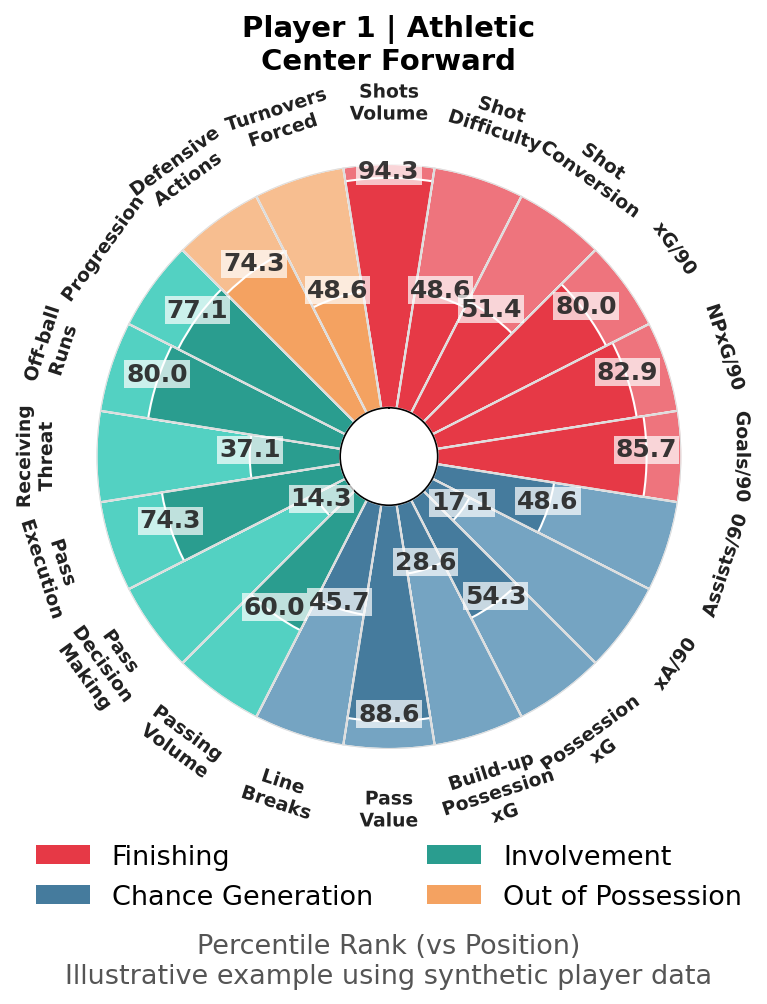

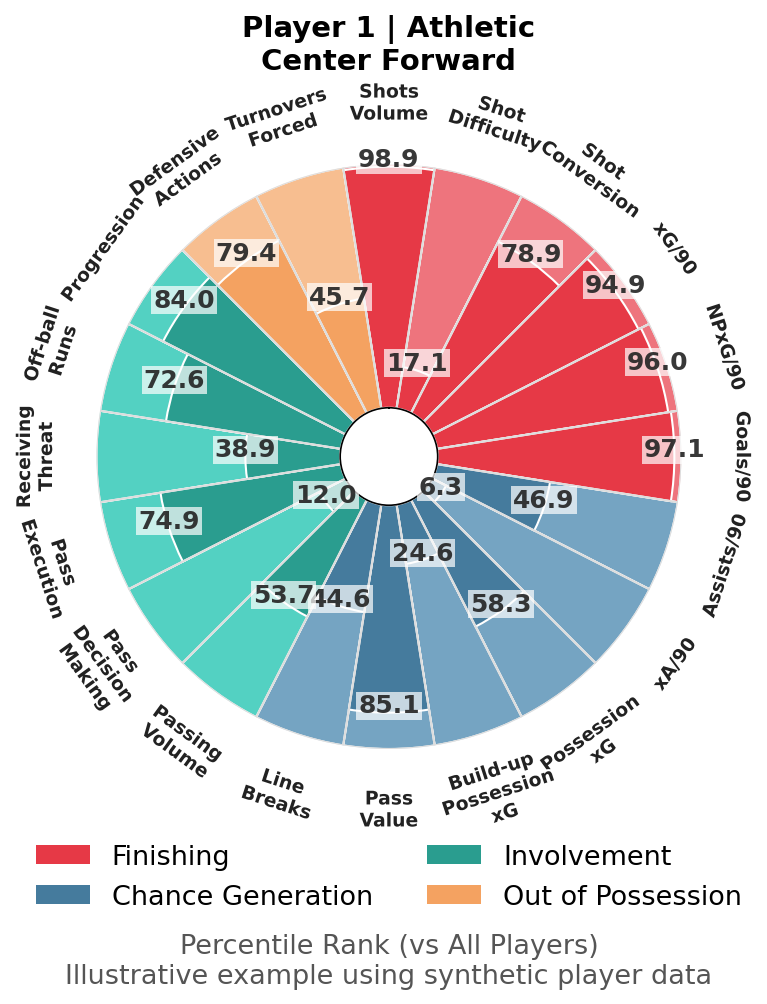

In [13]:
plot_player_profile(df_fake, "Player 1", mode="position")

plot_player_profile(df_fake, "Player 1", mode="global")

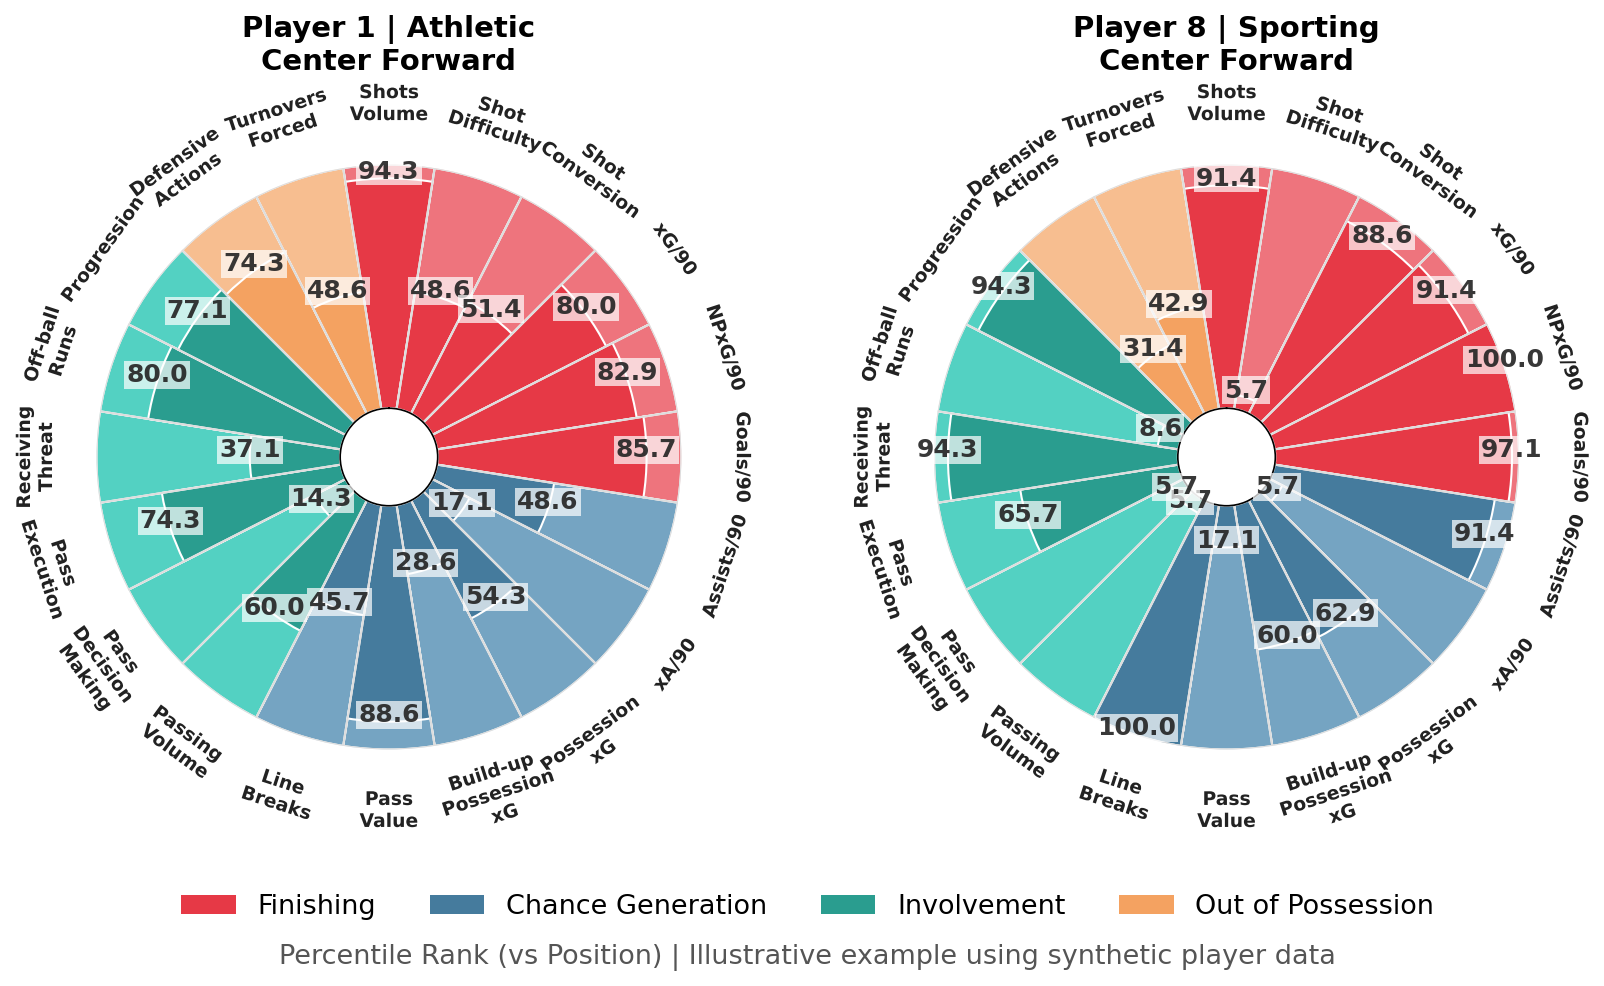

In [14]:
cf_players = df_fake[df_fake["position_group"] == "Center Forward"]

top_cf = cf_players.sort_values("NPxG90", ascending=False).iloc[0]["player_name"]

plot_player_profile(df_fake, ["Player 1", top_cf], mode="position")